In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pairs_trading.data.loaders import load_prices
from pairs_trading.config import SplitConfig, KalmanConfig
from pairs_trading.models.ols_hedge import OLSHedge
from pairs_trading.models.kalman_hedge import KalmanHedge
from pairs_trading.signals.zscore import rolling_zscore, generate_signal
from pairs_trading.backtest.engine import BacktestEngine

First let's build a dataframe containing all the tickers that we want to test. Split between train and test sets.

In [2]:
tickers = ["IAU", "GDX", "GLD", "SLV", "XLF", "KBE", "SPY", "IVV"]
df_train = load_prices(tickers, SplitConfig.train_start, SplitConfig.train_end, refresh=True)
df_test = load_prices(tickers, SplitConfig.val_start, SplitConfig.val_end, refresh=True)

[*********************100%***********************]  8 of 8 completed
[*********************100%***********************]  8 of 8 completed


Run the training-testing pipeline on all 4 pairs and return the resulting metrics

In [3]:
pairs = [["IAU", "GDX"],["GLD", "SLV"], ["XLF", "KBE"], ["SPY", "IVV"]]

First let's compute the dynamic beta and compare it to the static one

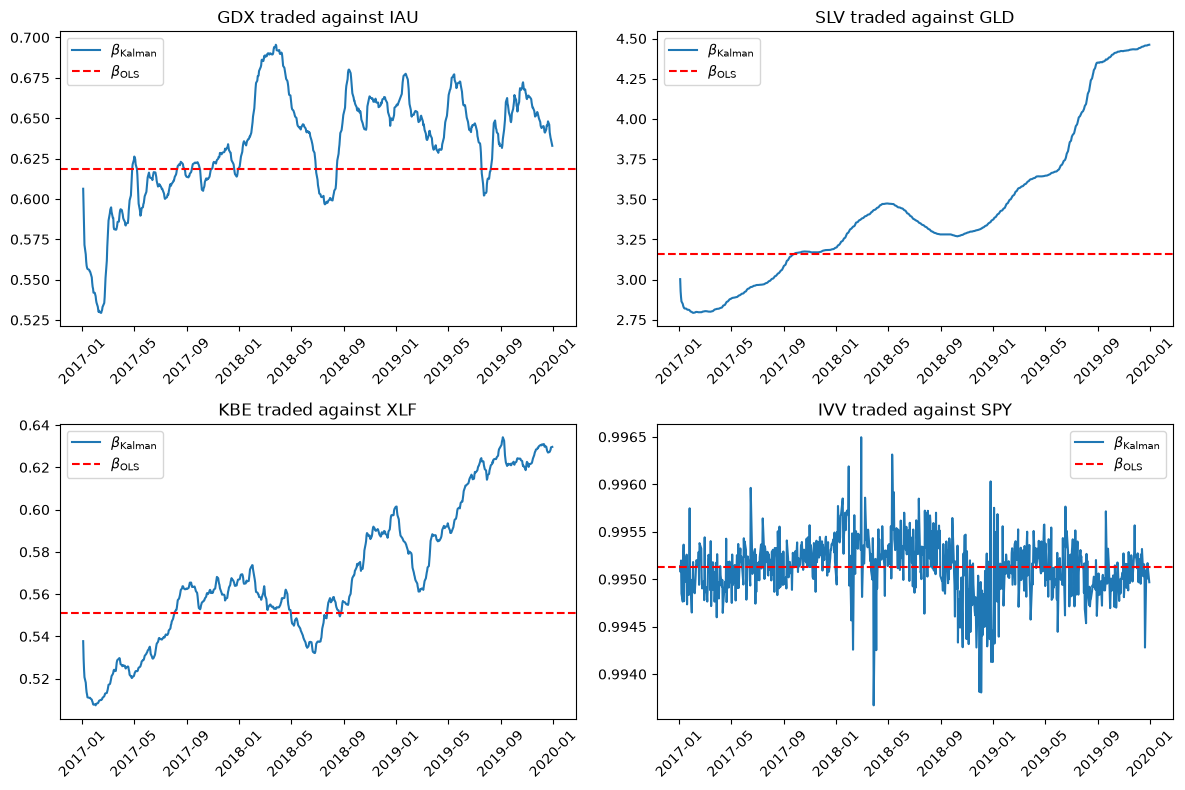

In [4]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):
    hedge_ols = OLSHedge()
    hedge_ols.fit(df_train[y], df_train[x])
    hedge_kalman = KalmanHedge()
    hedge_kalman.fit(df_train[y], df_train[x])

    axs[i].plot(hedge_kalman.beta, label=r"$\beta_\mathrm{Kalman}$")
    axs[i].axhline(y=hedge_ols.beta, color='r', linestyle='--', label=r"$\beta_\mathrm{OLS}$")
    
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

Next lets tune delta on the train set:

In [5]:
delta_values = np.logspace(-9, -1, 200)
rows = []
split = int(len(df_train) * 0.67)
df_delta_train = df_train.iloc[:split]
df_delta_val = df_train.iloc[split:]

for delta in delta_values:
    for y, x in pairs:
        hedge_ols = OLSHedge()
        hedge_ols.fit(df_delta_train[y], df_delta_train[x])
        residuals_ols = hedge_ols.spread(df_delta_val[y], df_delta_val[x])
        zscores_ols = rolling_zscore(residuals_ols)
        signals_ols = generate_signal(zscores_ols)

        config = KalmanConfig(delta = delta)
        hedge_kalman = KalmanHedge(config=config)
        hedge_kalman.fit(df_delta_train[y], df_delta_train[x])
        betas, alphas, res = hedge_kalman.transform(df_delta_val[y], df_delta_val[x])
        # zscores_kalman = rolling_zscore(res)
        # signals = generate_signal(zscores_kalman)
        engine_kalman = BacktestEngine()
        result_kalman = engine_kalman.run(df_delta_val[y], df_delta_val[x], signals_ols, betas)
        rows.append({"delta": delta, "pair": f"{x}/{y}", **result_kalman.metrics})

df_results = pd.DataFrame(rows).set_index(["pair", "delta"])
df_results.round(3)

,,sharpe,max_drawdown,hit_rate,average_holding_period,n_trades
pair,delta,,,,,
GDX/IAU,1.000000e-09,-0.408,0.041,0.435,29.333,3
SLV/GLD,1.000000e-09,0.874,0.059,0.507,15.500,5
KBE/XLF,1.000000e-09,-2.042,0.054,0.388,17.500,3
IVV/SPY,1.000000e-09,-2.479,0.007,0.250,2.333,5
GDX/IAU,1.096986e-09,-0.407,0.041,0.435,29.333,3
...,...,...,...,...,...,...
IVV/SPY,9.115888e-02,-2.473,0.007,0.250,2.333,5
GDX/IAU,1.000000e-01,-0.141,0.038,0.457,29.333,3
SLV/GLD,1.000000e-01,1.087,0.087,0.536,15.500,5


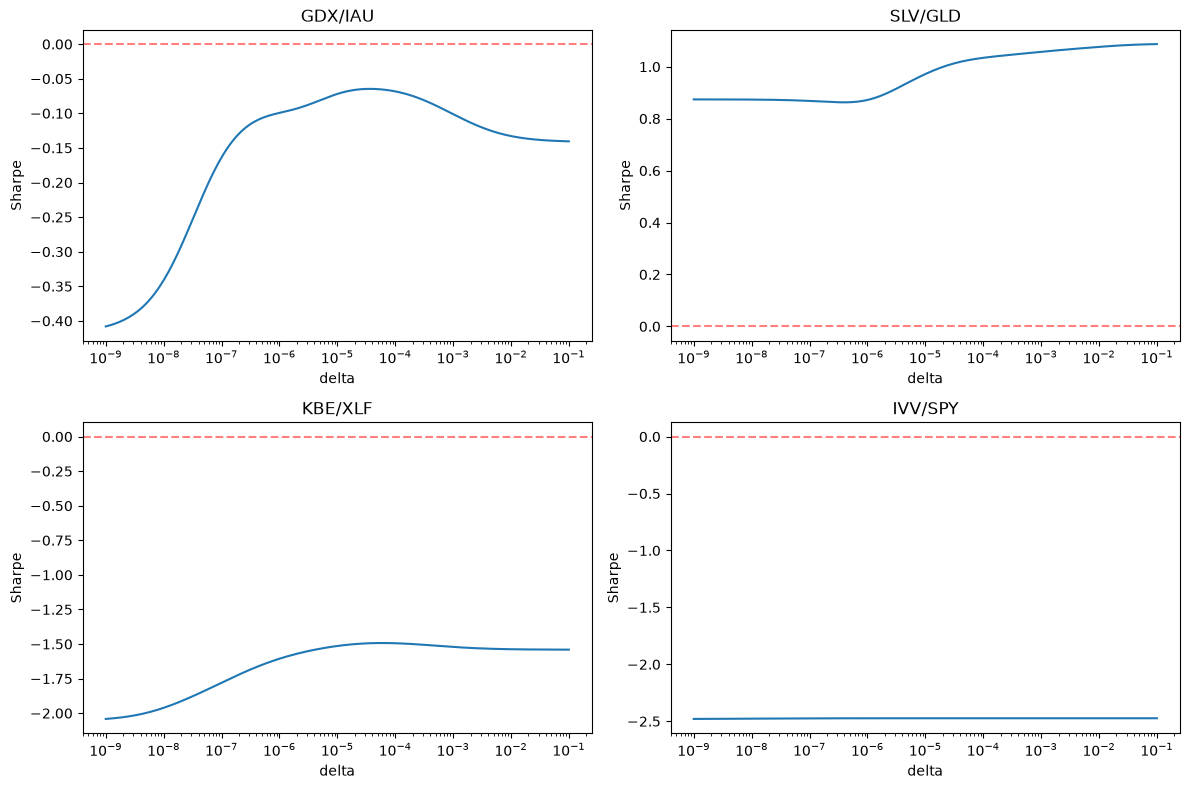

In [6]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, (y, x) in enumerate(pairs):
    pair_data = df_results.loc[f"{x}/{y}"]
    axs[i].plot(pair_data.index, pair_data["sharpe"])
    axs[i].set_xscale("log")
    axs[i].axhline(0, color="r", linestyle="--", alpha=0.5)
    axs[i].set_xlabel("delta")
    axs[i].set_ylabel("Sharpe")
    axs[i].set_title(f"{x}/{y}")

plt.tight_layout()
plt.show()

We pick the delta values with the best Sharpe ratios in the comparison with the OLS approach

Final test results for trading GDX against IAU:
OLS sharpe: 0.5760665508875475
Kalman sharpe: 0.49478561689439743
OLS max_drawdown: 0.0795232183826168
Kalman max_drawdown: 0.1061925282806612
OLS hit_rate: 0.4772727272727273
Kalman hit_rate: 0.4772727272727273
OLS average_holding_period: 14.642857142857142
Kalman average_holding_period: 14.642857142857142
OLS n_trades: 14
Kalman n_trades: 14
----------------------------------------


Final test results for trading SLV against GLD:
OLS sharpe: 0.12516891943625663
Kalman sharpe: 0.18958034045155872
OLS max_drawdown: 0.6412845130850412
Kalman max_drawdown: 0.8426884121690956
OLS hit_rate: 0.4767025089605735
Kalman hit_rate: 0.4767025089605735
OLS average_holding_period: 20.384615384615383
Kalman average_holding_period: 20.384615384615383
OLS n_trades: 13
Kalman n_trades: 13
----------------------------------------


Final test results for trading KBE against XLF:
OLS sharpe: 0.27354538552852087
Kalman sharpe: 0.15436009751419918
OLS max_dr

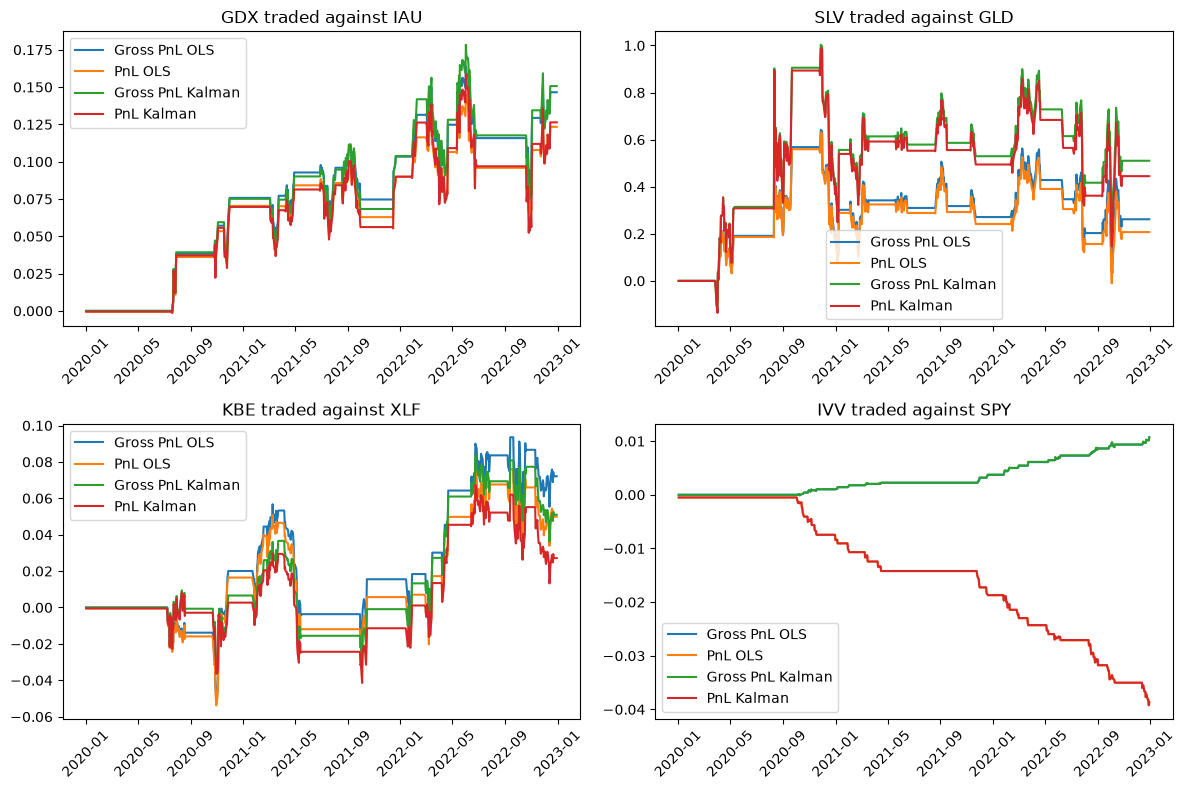

In [7]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axs = axs.flatten()
for i, (y, x) in enumerate(pairs):
    hedge_ols = OLSHedge()
    hedge_ols.fit(df_train[y], df_train[x])
    residuals_ols = hedge_ols.spread(df_test[y], df_test[x])
    zscores_ols = rolling_zscore(residuals_ols)
    signals_ols = generate_signal(zscores_ols)
    hedge_ols_ratios = pd.Series(hedge_ols.beta, index=signals_ols.index)
    engine_ols = BacktestEngine()
    result_ols = engine_ols.run(df_test[y], df_test[x], signals_ols, hedge_ols_ratios)


    hedge_kalman = KalmanHedge()
    hedge_kalman.fit(df_train[y], df_train[x])
    betas, alphas, res = hedge_kalman.transform(df_test[y], df_test[x])
    residuals_kalman = res

    # zscores_kalman = rolling_zscore(residuals_kalman)
    # signals_kalman = generate_signal(zscores_kalman)
    
    signals_kalman = generate_signal(zscores_ols)
    
    hedge_kalman_ratios = pd.Series(hedge_kalman.beta, index=signals_kalman.index)
    engine_kalman = BacktestEngine()
    result_kalman = engine_kalman.run(df_test[y], df_test[x], signals_kalman, hedge_kalman_ratios)
    print(f"Final test results for trading {x} against {y}:")
    for key in result_ols.metrics.keys():
        print(f"OLS {key}: {result_ols.metrics[key]}")
        print(f"Kalman {key}: {result_kalman.metrics[key]}")

    print("-"*40)
    print("\n")
    axs[i].plot(result_ols.gross_pnl.cumsum(), label="Gross PnL OLS")
    axs[i].plot(result_ols.pnl.cumsum(), label="PnL OLS")
    axs[i].plot(result_kalman.gross_pnl.cumsum(), label="Gross PnL Kalman")
    axs[i].plot(result_kalman.pnl.cumsum(), label="PnL Kalman")
    axs[i].legend()
    axs[i].set_title(f"{x} traded against {y}")
for ax in axs:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()